<a href="https://colab.research.google.com/github/pradhankuntal6-ship-it/EV-Battery-Health-Predictor-using-Machine-Learning/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from tqdm.notebook import tqdm

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)

In [3]:
from google.colab import files
uploaded = files.upload()   # select BATTERY_DATA_SET.zip

import zipfile, os

zip_name = list(uploaded.keys())[0]   # uses whatever name Colab actually saved it as
print("Uploaded file:", zip_name)

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("battery_dataset")

BASE_DIR = None
for root, dirs, fnames in os.walk("battery_dataset"):
    if "metadata.csv" in fnames:
        BASE_DIR = root
        break
print("Dataset folder:", BASE_DIR)

Saving BATTERY DATA SET.zip to BATTERY DATA SET.zip
Uploaded file: BATTERY DATA SET.zip
Dataset folder: battery_dataset/cleaned_dataset


In [4]:
meta = pd.read_csv(os.path.join(BASE_DIR, "metadata.csv"))

for col in ["Capacity", "Re", "Rct"]:
    meta[col] = pd.to_numeric(meta[col], errors="coerce")

meta = meta.sort_values(["battery_id", "uid"]).reset_index(drop=True)
print(meta.shape)
meta["type"].value_counts()

(7565, 10)


,count
type,
charge,2815
discharge,2794
impedance,1956


In [5]:
discharge = meta[meta["type"] == "discharge"].dropna(subset=["Capacity"]).copy()
discharge["cycle"] = discharge.groupby("battery_id").cumcount() + 1

data_dir = os.path.join(BASE_DIR, "data")

records = []
for _, row in tqdm(discharge.iterrows(), total=len(discharge)):
    fpath = os.path.join(data_dir, row["filename"])
    try:
        cyc = pd.read_csv(fpath)
        records.append({
            "battery_id": row["battery_id"],
            "uid": row["uid"],
            "cycle": row["cycle"],
            "ambient_temperature": row["ambient_temperature"],
            "Capacity": row["Capacity"],
            "mean_voltage": cyc["Voltage_measured"].mean(),
            "min_voltage": cyc["Voltage_measured"].min(),
            "mean_temperature": cyc["Temperature_measured"].mean(),
            "max_temperature": cyc["Temperature_measured"].max(),
            "discharge_duration_s": cyc["Time"].max(),
        })
    except Exception:
        continue

data = pd.DataFrame(records)
print(data.shape)
data.head()

  0%|          | 0/2769 [00:00<?, ?it/s]

(2769, 10)


,battery_id,uid,cycle,ambient_temperature,Capacity,mean_voltage,min_voltage,mean_temperature,max_temperature,discharge_duration_s
0,B0005,5122,1,24,1.856487,3.529829,2.612467,32.572328,38.982181,3690.234
1,B0005,5124,2,24,1.846327,3.537320,2.587209,32.725235,39.033398,3672.344
2,B0005,5126,3,24,1.835349,3.543737,2.651917,32.642862,38.818797,3651.641
3,B0005,5128,4,24,1.835263,3.543666,2.592948,32.514876,38.762305,3631.563
4,B0005,5130,5,24,1.834646,3.542343,2.547420,32.382349,38.665393,3629.172


In [6]:
impedance = meta[meta["type"] == "impedance"].dropna(subset=["Re"])[["battery_id", "uid", "Re", "Rct"]]

merged = []
for bid, grp in data.groupby("battery_id"):
    imp_grp = impedance[impedance["battery_id"] == bid].sort_values("uid")
    imp_grp = imp_grp.drop(columns=["battery_id"])   # avoid duplicate column on merge
    grp_sorted = grp.sort_values("uid")
    m = pd.merge_asof(grp_sorted, imp_grp, on="uid", direction="nearest")
    merged.append(m)

data = pd.concat(merged, ignore_index=True)
data["Re"] = data.groupby("battery_id")["Re"].transform(lambda x: x.fillna(x.median()))
data["Rct"] = data.groupby("battery_id")["Rct"].transform(lambda x: x.fillna(x.median()))
data.head()

,battery_id,uid,cycle,ambient_temperature,Capacity,mean_voltage,min_voltage,mean_temperature,max_temperature,discharge_duration_s,Re,Rct
0,B0005,5122,1,24,1.856487,3.529829,2.612467,32.572328,38.982181,3690.234,0.044669,0.069456
1,B0005,5124,2,24,1.846327,3.537320,2.587209,32.725235,39.033398,3672.344,0.044669,0.069456
2,B0005,5126,3,24,1.835349,3.543737,2.651917,32.642862,38.818797,3651.641,0.044669,0.069456
3,B0005,5128,4,24,1.835263,3.543666,2.592948,32.514876,38.762305,3631.563,0.044669,0.069456
4,B0005,5130,5,24,1.834646,3.542343,2.547420,32.382349,38.665393,3629.172,0.044669,0.069456


In [7]:
data["initial_capacity"] = data.groupby("battery_id")["Capacity"].transform("first")
data["capacity_ratio"] = data["Capacity"] / data["initial_capacity"]

def label_health(ratio):
    if ratio >= 0.90:
        return "Healthy"
    elif ratio >= 0.70:
        return "Degrading"
    else:
        return "Critical"

data["health_status"] = data["capacity_ratio"].apply(label_health)
data["health_status"].value_counts()

,count
health_status,
Healthy,1753
Degrading,678
Critical,338


In [8]:
data = data.dropna().drop_duplicates().reset_index(drop=True)

stats = data[["Capacity", "capacity_ratio", "mean_voltage", "min_voltage",
              "mean_temperature", "max_temperature", "discharge_duration_s",
              "Re", "Rct", "cycle"]].describe()
display(stats)

data.to_csv("cleaned_battery_dataset.csv", index=False)
stats.to_csv("dataset_statistics.csv")
print("Saved cleaned_battery_dataset.csv and dataset_statistics.csv")

,Capacity,capacity_ratio,mean_voltage,min_voltage,mean_temperature,max_temperature,discharge_duration_s,Re,Rct,cycle
count,2769.000000,2769.000000,2769.000000,2769.000000,2769.000000,2769.000000,2769.000000,2.769000e+03,2.769000e+03,2769.000000
mean,1.326543,2.779316,3.431279,2.321417,26.961265,34.466999,3227.853332,-6.998371e+11,1.484900e+12,60.775009
std,0.472517,5.504970,0.198454,0.308955,13.879652,16.333938,1388.749019,2.603544e+13,5.524145e+13,48.303932
min,0.000000,0.000000,2.530010,0.192738,4.857764,6.383481,23.000000,-9.689245e+14,3.954262e-02,1.000000
25%,1.150286,0.800365,3.367454,2.074341,11.647249,17.275372,2522.375000,6.343709e-02,9.116726e-02,21.000000
50%,1.428065,0.986144,3.416749,2.381871,31.323263,37.882588,3031.953000,7.860662e-02,1.283307e-01,48.000000
75%,1.673645,1.648474,3.491746,2.622275,34.276432,42.718192,3390.281000,1.014554e-01,1.742424e-01,91.000000
max,2.640149,27.550168,4.452558,3.838396,58.954811,69.869746,6574.671000,1.798412e-01,2.055843e+15,197.000000


Saved cleaned_battery_dataset.csv and dataset_statistics.csv


In [9]:
features = ["cycle", "ambient_temperature", "mean_voltage", "min_voltage",
            "mean_temperature", "max_temperature", "discharge_duration_s", "Re", "Rct"]
X = data[features]
y = data["health_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

Accuracy: 0.9693
              precision    recall  f1-score   support

     Healthy       0.99      0.98      0.98       351
   Degrading       0.93      0.96      0.94       136
    Critical       0.97      0.96      0.96        67

    accuracy                           0.97       554
   macro avg       0.96      0.96      0.96       554
weighted avg       0.97      0.97      0.97       554



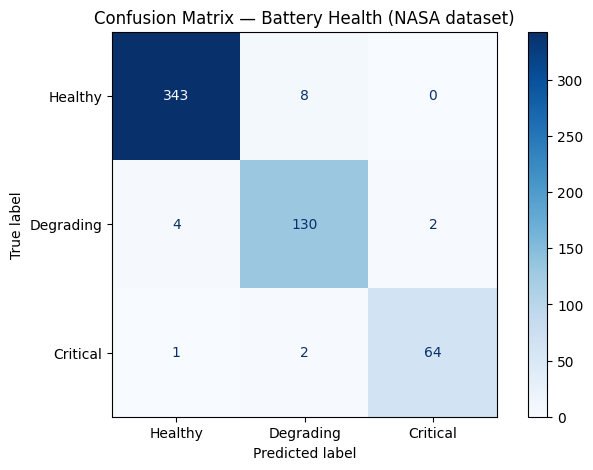

In [10]:
labels = ["Healthy", "Degrading", "Critical"]
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, labels=labels))

cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Battery Health (NASA dataset)")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

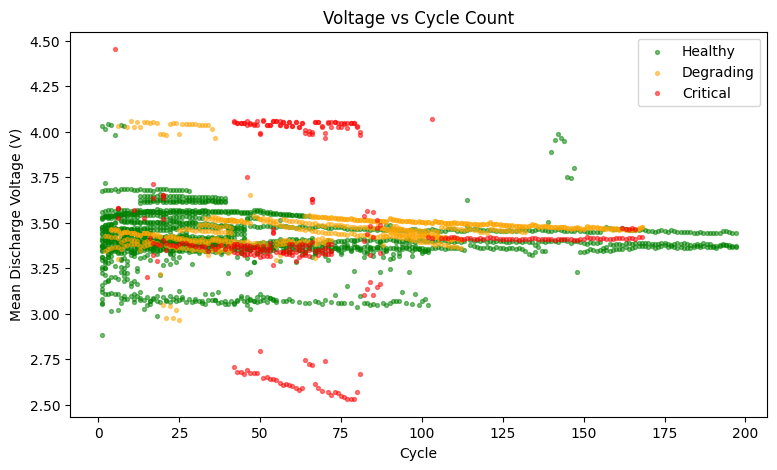

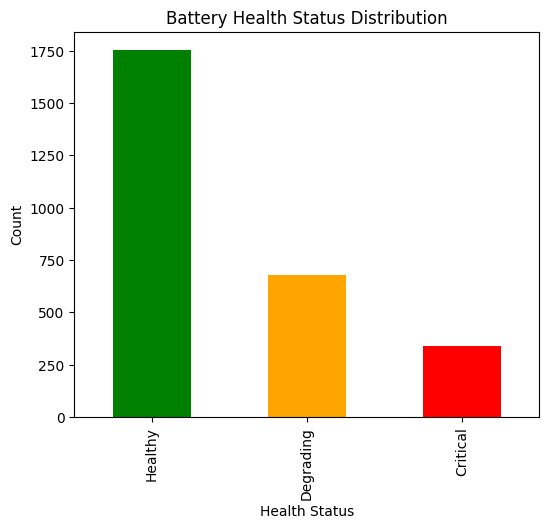

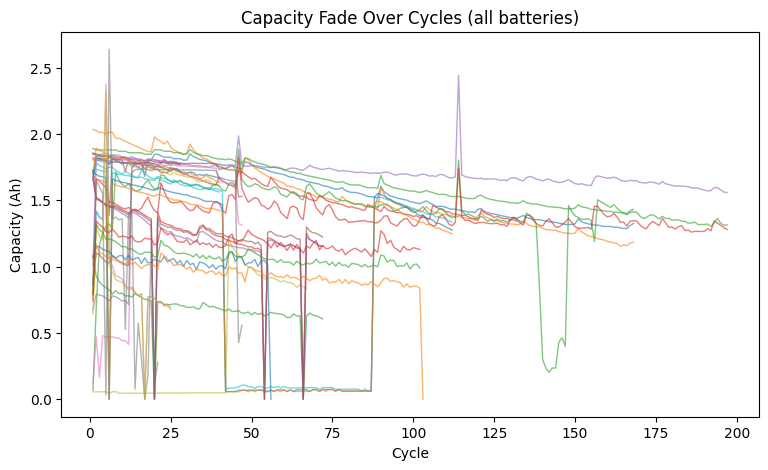

In [11]:
plt.figure(figsize=(9,5))
for status, color in zip(labels, ["green","orange","red"]):
    sub = data[data["health_status"] == status]
    plt.scatter(sub["cycle"], sub["mean_voltage"], s=8, alpha=0.5, label=status, color=color)
plt.xlabel("Cycle"); plt.ylabel("Mean Discharge Voltage (V)")
plt.title("Voltage vs Cycle Count")
plt.legend()
plt.savefig("chart1_voltage_vs_cycle.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6,5))
data["health_status"].value_counts().reindex(labels).plot(kind="bar", color=["green","orange","red"])
plt.xlabel("Health Status"); plt.ylabel("Count")
plt.title("Battery Health Status Distribution")
plt.savefig("chart2_health_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9,5))
for bid, grp in data.groupby("battery_id"):
    plt.plot(grp["cycle"], grp["Capacity"], alpha=0.6, linewidth=1)
plt.xlabel("Cycle"); plt.ylabel("Capacity (Ah)")
plt.title("Capacity Fade Over Cycles (all batteries)")
plt.savefig("chart3_capacity_fade.png", dpi=150, bbox_inches="tight")
plt.show()

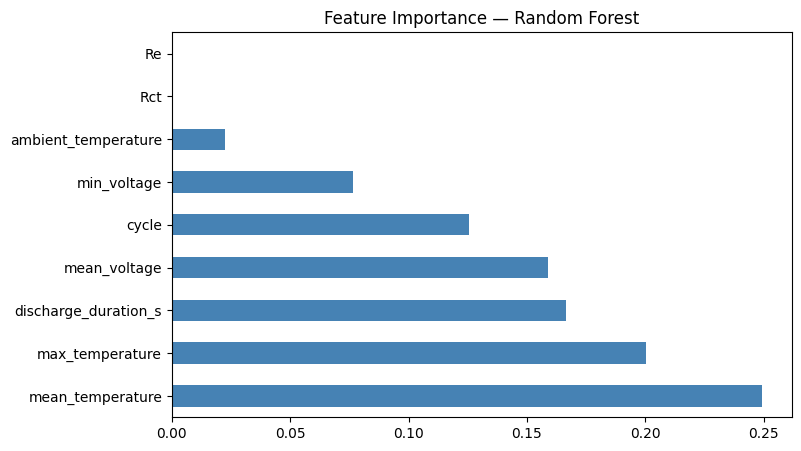

mean_temperature        0.249471
max_temperature         0.200189
discharge_duration_s    0.166516
mean_voltage            0.158875
cycle                   0.125495
min_voltage             0.076710
ambient_temperature     0.022498
Rct                     0.000141
Re                      0.000106
dtype: float64


In [12]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
importance.plot(kind="barh", color="steelblue")
plt.title("Feature Importance — Random Forest")
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(importance)